Całość ma na celu stworzenie algorytmu klasyfikacji drzew od podstaw (czyli bez żadnych gotowych rozwiązań, ale numpy, pandas itp. dozwolone) oraz porównanie wyników z innymi metodami, takimi jak: KNN, Regresja logistyczna i Random Forest.

Poniższa sekcja zawiera klase i funkcje używane później do stworzenia drzewa i predykcji za jego pomocą, tak samo jak index Giniego.

In [1]:
import pandas as pd



class Node:
    def __init__(self, feature=None, children=None, label=None):
        self.feature = feature # cecha do podziału
        self.children = children or {}  # dict: wartość -> Node
        self.label = label # jeśli liść


def gini_index(dane_frame, cecha : str):
    n = dane_frame.shape[0]
    grouped = dane_frame.groupby(cecha)
    
    gini_value = 0

    for x, dataframe in grouped:
        rows = dataframe.shape[0]

        sum_edible = (dataframe['class'] == 'e').sum()
        sum_poisonous = (dataframe['class'] == 'p').sum()

        g = 1 - pow(sum_edible/rows, 2) - pow(sum_poisonous/rows, 2)
        w = rows/n
        gini_value += w*g
    
    return gini_value, cecha


def best_feature(df, features):
    best = None
    best_gini = float('inf') # Pozytywna nieskończoność, bo index giniego ma być jak najmniejszy

    for feature in features:
        g = gini_index(df, feature)[0]
        if g < best_gini:
            best_gini = g
            best = feature

    return best


def predict(node, sample):
    if node.label is not None:
        return node.label

    value = sample[node.feature]

    if value in node.children:
        return predict(node.children[value], sample)
    else:
        return None
    

def build_tree(df, features, depth=0, max_depth=10):
    # jeśli wszystkie klasy takie same, to liść
    if len(df['class'].unique()) == 1:
        return Node(label=df['class'].iloc[0])

    # warunek stopu
    if depth >= max_depth or len(features) == 0:
        return Node(label=df['class'].mode()[0])

    # wybór najlepszej cechy
    best = best_feature(df, features)
    node = Node(feature=best)

    for value, subset in df.groupby(best):
        if subset.empty:
            node.children[value] = Node(label=df['class'].mode()[0])
        else:
            node.children[value] = build_tree(
                subset,
                [f for f in features if f != best],
                depth + 1,
                max_depth
            )

    return node


Poniżej jest kod budowania drzewa, i oceny jego predykcji

In [2]:
import pandas as pd


df = pd.read_csv("mushrooms.csv")
print(f"Dataset shape: {df.shape}")
print(f"Class distribution:\n{df['class'].value_counts()}\n")
 

# Podział na test i train
df = df.sample(frac=1, random_state=42).reset_index(drop=True) 
split_idx = int(len(df) * 0.8)
train_df  = df.iloc[:split_idx].reset_index(drop=True)
test_df   = df.iloc[split_idx:].reset_index(drop=True)
print(f"Training samples : {len(train_df)}")
print(f"Testing  samples : {len(test_df)}\n")
 
 
# Budowanie drzewa
features = [col for col in df.columns if col != "class"]
tree = build_tree(train_df, features, depth=0, max_depth=10)
 

def evaluate(tree, test_df):
    correct = 0
    total   = len(test_df)
    unknown = 0
 
    for _, row in test_df.iterrows():
        prediction = predict(tree, row)
 
        if prediction is None:
            unknown += 1
            continue
 
        if prediction == row["class"]:
            correct += 1
 
    accuracy = correct / (total - unknown) if (total - unknown) > 0 else 0
    return accuracy, correct, total, unknown

 
accuracy, correct, total, unknown = evaluate(tree, test_df)
 
print("── Wyniki ──────────────")
print(f"Correct predictions: {correct} / {total - unknown}")
print(f"Unpredictable rows: {unknown} (Takie z brakującymi danymi)")
print(f"Accuracy: {accuracy * 100:.2f}%\n")
 
 
# Pokaz paru wartości
print("── Predykcja dla 5 pierwszych wierszy─────────")
print(f"{'#':<4} {'Aktualne':<10} {'Predykcja':<10} {'Poprawność'}")
print("-" * 36)
 
for i, (_, row) in enumerate(test_df.head(5).iterrows()):
    actual = row["class"]
    predicted = predict(tree, row)
    mark = "ok" if predicted == actual else "false"
    print(f"{i+1:<4} {'edible' if actual == 'e' else 'poisonous':<10} "
          f"{'edible' if predicted == 'e' else 'poisonous':<10} {mark}")


Dataset shape: (8124, 23)
Class distribution:
class
e    4208
p    3916
Name: count, dtype: int64

Training samples : 6499
Testing  samples : 1625

── Wyniki ──────────────
Correct predictions: 1625 / 1625
Unpredictable rows: 0 (Takie z brakującymi danymi)
Accuracy: 100.00%

── Predykcja dla 5 pierwszych wierszy─────────
#    Aktualne   Predykcja  Poprawność
------------------------------------
1    edible     edible     ok
2    poisonous  poisonous  ok
3    poisonous  poisonous  ok
4    poisonous  poisonous  ok
5    poisonous  poisonous  ok


Poniżej jest porówananie i implementacja 3 kolejnych metod: KNN, Regresji i drzew losowych

In [5]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
 

df = pd.read_csv("mushrooms.csv")
print(f"Dataset shape : {df.shape}")
print(f"Class distribution:\n{df['class'].value_counts()}\n")


encoders = {}
df_encoded = df.copy()
for col in df.columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col])
    encoders[col] = le


X = df_encoded.drop(columns=["class"])
y = df_encoded["class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
 
print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}\n")
 
results = {}
 
 
# Statystyki
def evaluate(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(
        y_test, y_pred,
        target_names=encoders["class"].classes_,
        zero_division=0
    )
    print(f"── {name} {'─' * (55 - len(name))}")
    print(f"Accuracy : {accuracy * 100:.2f}%")
    print(report)
    return accuracy
 
 
# 1. Random Forest
rf = RandomForestClassifier(n_estimators=50, random_state=42)
rf.fit(X_train, y_train)
results["Random Forest"] = evaluate("Random Forest", rf, X_test, y_test)
 
 
# 2. Logistic Regression
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
 
lr = LogisticRegression(max_iter=100, random_state=42, solver="lbfgs")
lr.fit(X_train_s, y_train)
results["Logistic Regression"] = evaluate("Logistic Regression", lr, X_test_s, y_test)
 
 
# 3. KNN
knn = KNeighborsClassifier(n_neighbors=2, metric="euclidean")
knn.fit(X_train, y_train)
results["KNN"] = evaluate("KNN", knn, X_test, y_test)
 
 
# ── 5. Summary ────────────────────────────────────────────────────────────────
print("=" * 58)
print(f"{'PODSUMOWANIE DLA ACCURACY':^58}")
print("=" * 58)
print(f"  {'Algorytm':<35} {'Accuracy':>10}")
print("-" * 58)
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"  {name:<35} {acc*100:>9.2f}%")
print("=" * 58)

Dataset shape : (8124, 23)
Class distribution:
class
e    4208
p    3916
Name: count, dtype: int64

Training samples : 6499
Testing  samples : 1625

── Random Forest ──────────────────────────────────────────
Accuracy : 100.00%
              precision    recall  f1-score   support

           e       1.00      1.00      1.00       842
           p       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

── Logistic Regression ────────────────────────────────────
Accuracy : 96.25%
              precision    recall  f1-score   support

           e       0.96      0.96      0.96       842
           p       0.96      0.96      0.96       783

    accuracy                           0.96      1625
   macro avg       0.96      0.96      0.96      1625
weighted avg       0.96      0.96      0.96      1625

── KNN ─────────────────────────────────

Poniżej wizualizacja drzewa powstałego wcześniej

Tree saved to decision_tree.png


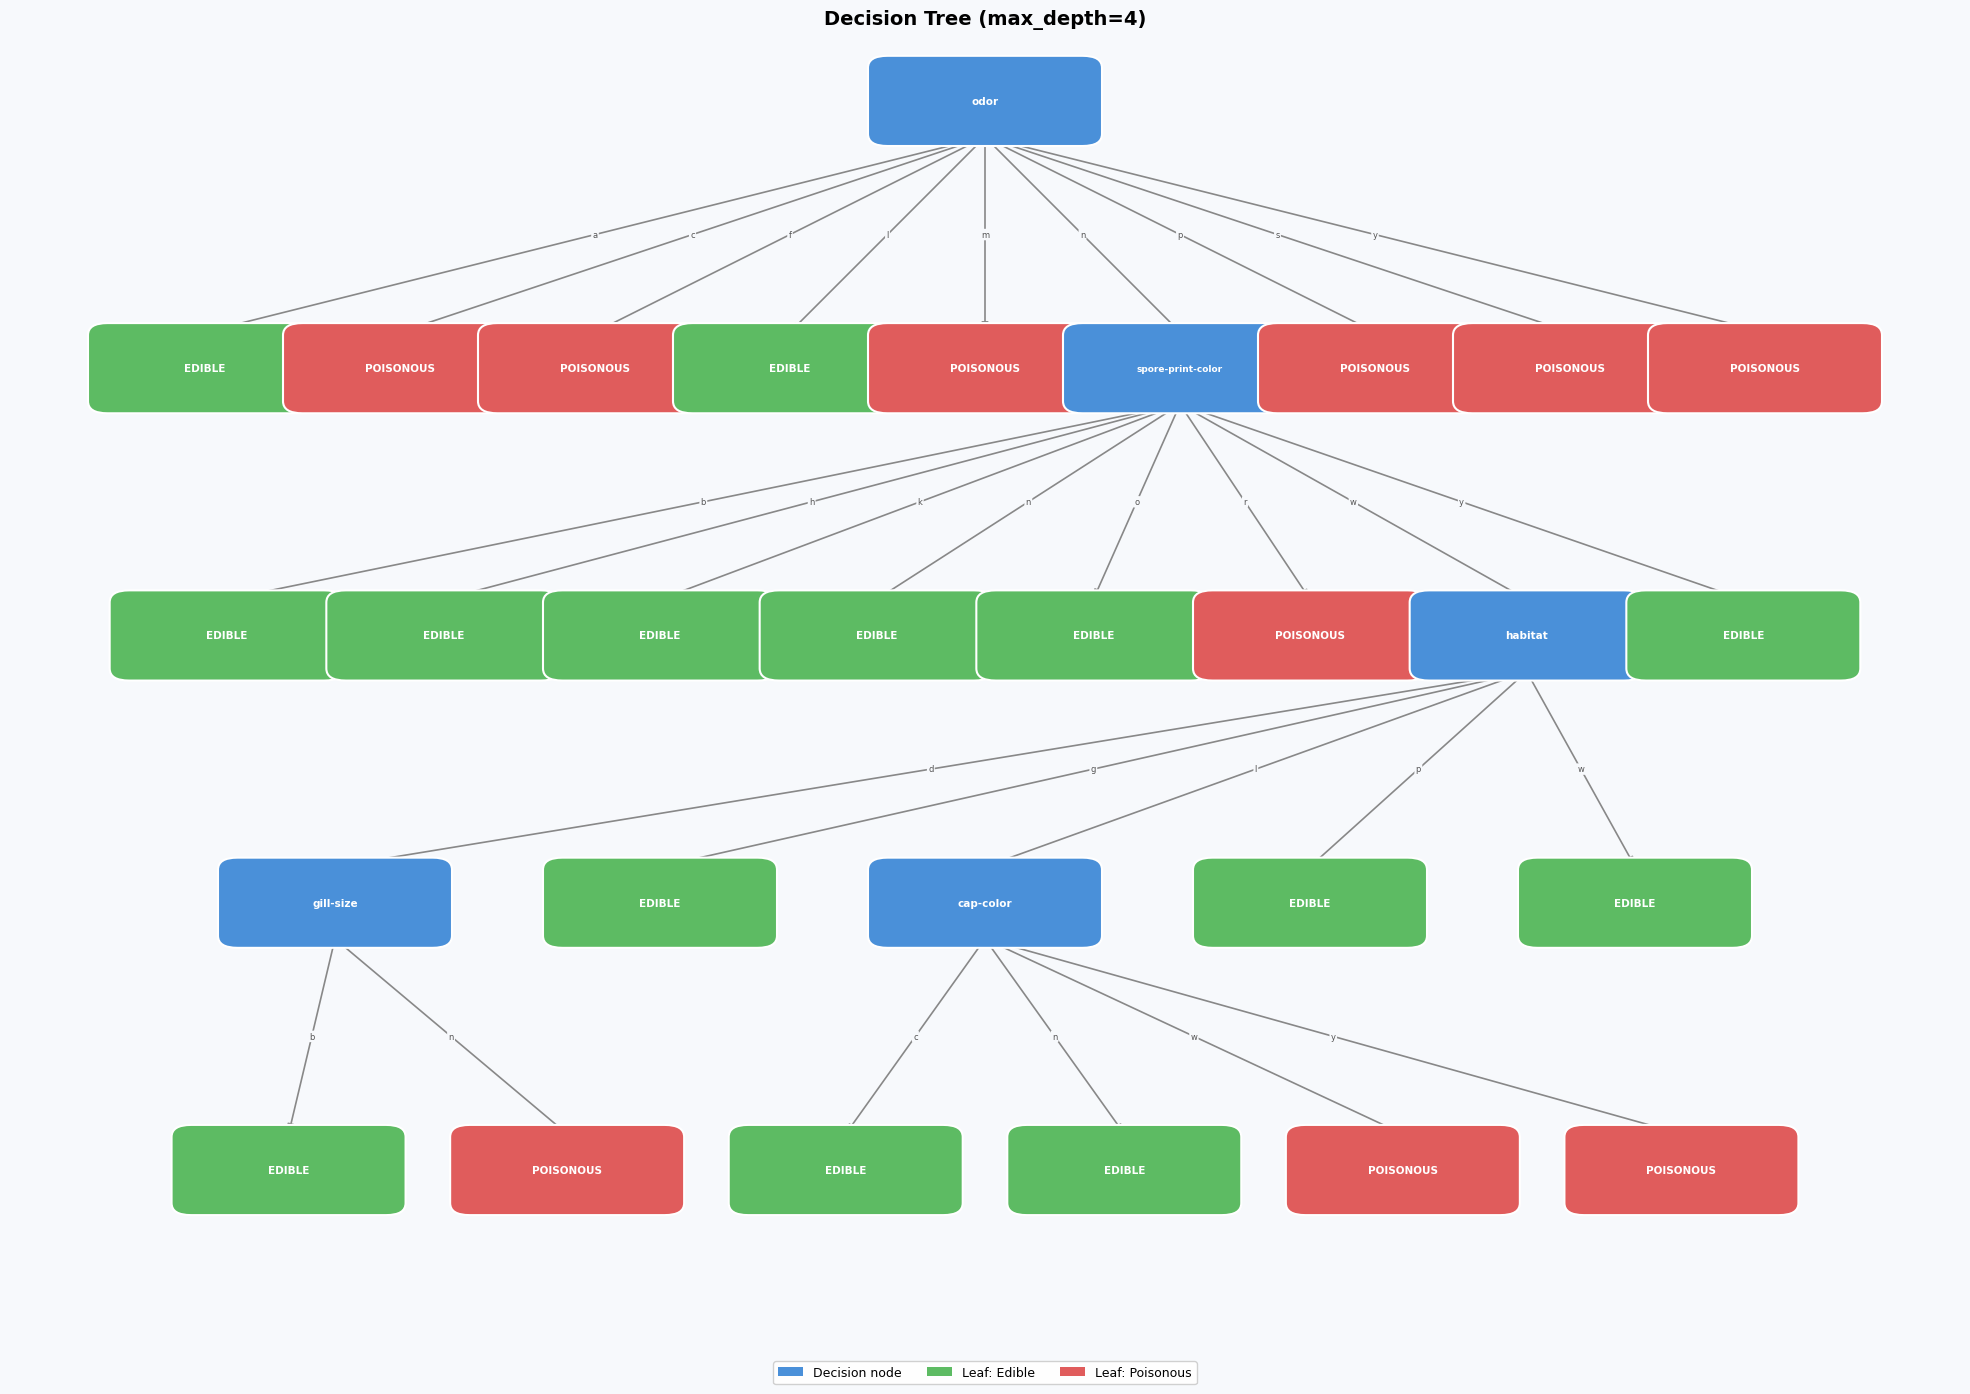

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Config ────────────────────────────────────────────────────────────────────
MAX_DEPTH     = 4      # keep the drawing readable (full tree is huge)
OUTPUT_FILE   = "decision_tree.png"
DPI           = 180
 
COLORS = {
    "node": "#4A90D9",
    "leaf_e":"#5DBB63",   # edible   → green
    "leaf_p":"#E05C5C",   # poisonous → red
    "edge":"#888888",
    "node_text": "white",
    "leaf_text": "white",
    "bg":"#F7F9FC",
}

def collect_nodes(node, depth=0, parent_id=None, edge_label="", nodes=None, edges=None):
    if nodes is None:
        nodes = []
        edges = []
    node_id = len(nodes)
    nodes.append({"id": node_id, "depth": depth, "node": node, "edge_label": edge_label})
    if parent_id is not None:
        edges.append((parent_id, node_id, edge_label))
    if node.label is None:
        for val, child in node.children.items():
            collect_nodes(child, depth + 1, node_id, str(val), nodes, edges)
    return nodes, edges
 
nodes, edges = collect_nodes(tree)
 
# Count nodes per depth to space them horizontally
from collections import defaultdict
depth_counts  = defaultdict(int)
depth_indices = defaultdict(int)
for n in nodes:
    depth_counts[n["depth"]] += 1
 
max_width = max(depth_counts.values())
 
# Assign x positions: spread evenly within [0, 1]
positions = {}
for n in nodes:
    d   = n["depth"]
    idx = depth_indices[d]
    cnt = depth_counts[d]
    x   = (idx + 1) / (cnt + 1)       # evenly spaced in [0,1]
    y   = 1.0 - d / (MAX_DEPTH + 0.5) # top = depth 0
    positions[n["id"]] = (x, y)
    depth_indices[d] += 1
 
 
# ── 3. Draw ───────────────────────────────────────────────────────────────────
fig_w = max(14, max_width * 2.2)
fig_h = (MAX_DEPTH + 1) * 2.8
 
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
fig.patch.set_facecolor(COLORS["bg"])
ax.set_facecolor(COLORS["bg"])
ax.axis("off")
ax.set_xlim(0, 1)
ax.set_ylim(-0.05, 1.05)
 
# Build a quick id→node dict
id_to_node = {n["id"]: n for n in nodes}
 
# Draw edges first (so they sit behind boxes)
for parent_id, child_id, label in edges:
    px, py = positions[parent_id]
    cx, cy = positions[child_id]
    ax.annotate(
        "", xy=(cx, cy + 0.03), xytext=(px, py - 0.03),
        arrowprops=dict(arrowstyle="-|>", color=COLORS["edge"], lw=1.2)
    )
    mx, my = (px + cx) / 2, (py + cy) / 2
    ax.text(mx, my, label, fontsize=6, ha="center", va="center",
            color="#555555",
            bbox=dict(boxstyle="round,pad=0.15", fc=COLORS["bg"], ec="none"))
 
# Draw nodes
BOX_W = 0.10
BOX_H = 0.055
 
for n in nodes:
    nid  = n["id"]
    node = n["node"]
    x, y = positions[nid]
 
    if node.label is not None:
        # Leaf
        color = COLORS["leaf_e"] if node.label == "e" else COLORS["leaf_p"]
        label_str = "EDIBLE" if node.label == "e" else "POISONOUS"
    else:
        color     = COLORS["node"]
        label_str = node.feature
 
    fancy = mpatches.FancyBboxPatch(
        (x - BOX_W / 2, y - BOX_H / 2), BOX_W, BOX_H,
        boxstyle="round,pad=0.01",
        linewidth=1.5,
        edgecolor="white",
        facecolor=color,
        zorder=3,
        transform=ax.transData
    )
    ax.add_patch(fancy)
 
    fontsize = 6.5 if len(label_str) > 14 else 7.5
    ax.text(x, y, label_str, ha="center", va="center",
            fontsize=fontsize, fontweight="bold",
            color=COLORS["node_text"], zorder=4, wrap=True)
 
# Legend
legend_elements = [
    mpatches.Patch(facecolor=COLORS["node"],   label="Decision node"),
    mpatches.Patch(facecolor=COLORS["leaf_e"], label="Leaf: Edible"),
    mpatches.Patch(facecolor=COLORS["leaf_p"], label="Leaf: Poisonous"),
]
ax.legend(handles=legend_elements, loc="lower center",
          ncol=3, fontsize=9, framealpha=0.9,
          bbox_to_anchor=(0.5, -0.02))
 
plt.title(f"Decision Tree (max_depth={MAX_DEPTH})", fontsize=14, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(OUTPUT_FILE, dpi=DPI, bbox_inches="tight")
print(f"Tree saved to {OUTPUT_FILE}")
plt.show()